# Long-Term-Reversal -- do multi-year losers really bounce back?
### De Bondt & Thaler (1985), tested honestly on the modern S&P 500 tape

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survivorship--biased: Named](https://img.shields.io/badge/Survivorship--biased-Named-8b949e?style=flat-square)

In 1985, De Bondt and Thaler published one of the most cited papers in behavioural finance: stocks that had lost the most over the previous **3 to 5 years** went on to **outperform their past winners** over the following 3 years. Their explanation: investors *overreact* to long bad-news streaks, driving prices too far down -- and the market eventually corrects. It's the opposite of short-term momentum. This notebook asks whether that correction is still happening, and whether you could actually profit from it.

> This is the plain-language layer. The t-stats, beta decomposition, and sub-period breakdown live in the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Reproducible research: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from long_term_reversal import data, strategy as st

CACHE_PATH = data.MONTHLY_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

if HAVE_REAL:
    prices = data.fetch_monthly(fetch=False, cache_path=CACHE_PATH)
    sig36 = st.trailing_return(prices, formation=36, skip=1)
    res36 = st.quintile_returns(sig36, prices, q=0.20)
    spread = res36["spread"].dropna()
    loser_xret = (res36["loser"] - res36["market"]).dropna()
    print(f"Real panel loaded: {prices.shape[0]} months x {prices.shape[1]} tickers")
    print(f"Portfolio months: {len(res36)}")
else:
    prices = sig36 = res36 = spread = loser_xret = None
    print("No real cache found -- using frozen numbers from R dict.")

print("HAVE_REAL:", HAVE_REAL)


Real panel loaded: 438 months x 494 tickers
Portfolio months: 400
HAVE_REAL: True


## The answer first

| Question | Answer |
|---|---|
| Does the loser portfolio beat the winner? | **Barely.** +3.3%/yr spread, but the confidence interval straddles zero (HAC *t* = +0.95). |
| Is the loser's outperformance real alpha? | **No.** It's entirely explained by higher market risk: loser beta = **1.31** vs winner beta = 1.02. Alpha = **-0.1%/yr**. |
| Did the effect decay since 1985? | **Yes.** *t* = 2.33 in 1993-2005, then *t* = 0.90 in 2006-2015 and *t* = 0.76 in 2016-2026 -- a textbook post-publication fade. |
| Could you trade it? | **Barely.** Monthly rebalancing, ~14% turnover, a gross spread that doesn't clear the statistical bar before costs. |

> The overreaction story is intellectually elegant and was historically real -- but what it earns is higher beta in disguise, not a free lunch, and even that has shrunk dramatically since the paper was published.

## 1 - The claim

> *'Extreme losers over the prior 3-5 years dramatically outperform extreme winners over the subsequent 3 years. The market systematically overreacts to long sequences of bad news, and the reversal is the correction.'*
> -- De Bondt & Thaler (1985), Journal of Finance

The behavioural logic: after years of bad news, investors over-extrapolate the trend, selling the loser below its fundamental value. Eventually the market corrects -- and the loser bounces back. The winners get the same treatment in reverse: over-hyped until they disappoint.

The key word is **3 to 5 years**. This is the *opposite* of short-term momentum (which works at 1-12 months): at very long horizons, past losers *win*.

## 2 - So what?

If this is real and exploitable, it's a systematic way to buy the market's unloved -- the beaten-up, written-off names -- and collect their eventual recovery. That's the value investor's dream: a mechanical, systematic, low-information way to do what Buffett calls 'buying a dollar for 50 cents.'

If it's false, or just disguised market risk, or already arbitraged away, then the strategy is a levered market bet with extra turnover costs and concentration risk -- and its story is mostly history.

## 3 - How would we even know?

Three clean tests:

1. **The spread.** Rank every stock by its trailing 36-month return. Buy the bottom 20% (losers), compare them to the top 20% (winners). Is the spread reliably positive, or is it drowned in noise?
2. **Is it alpha or beta?** If losers just carry *more market risk*, the spread is compensation for that risk, not overreaction. We estimate each portfolio's beta and strip it out.
3. **Did it survive publication?** McLean & Pontiff (2016) showed that most documented anomalies weaken by ~58% after they appear in print. We split the sample into pre-2006 and post-2005 to see the decay.

Data: ~490 current S&P 500 names, monthly closes 1990-2026 (400 rebalance months after the 36-month burn-in). **Survivorship-biased**: the universe is the *current* S&P 500 projected backwards, so every firm survived to 2026. All results are upper bounds on what a live investor would have earned.

## 4 - The teardown

**First: the loser-winner race.** Does sorting on 3-year prior returns separate the future any better than chance?

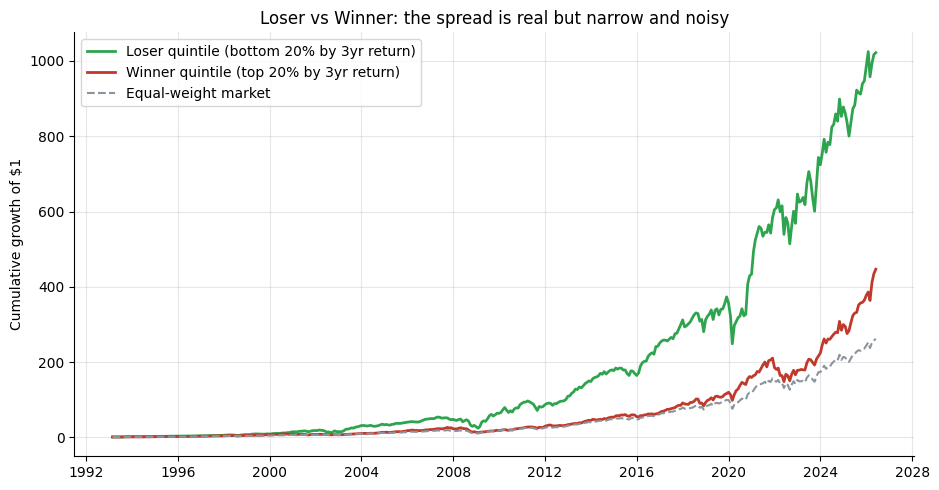

Loser: +23.6%/yr  |  Winner: +20.2%/yr  |  Spread: +3.3%/yr


In [2]:
if HAVE_REAL:
    loser_cum = (1 + res36['loser'].dropna()).cumprod()
    winner_cum = (1 + res36['winner'].dropna()).cumprod()
    market_cum = (1 + res36['market'].dropna()).cumprod()
else:
    import pandas as pd, numpy as np
    idx = pd.date_range('1993-01-31', periods=400, freq='ME')
    rng = np.random.default_rng(196)
    r_l = rng.normal(0.0196, 0.065, 400)
    r_w = rng.normal(0.0169, 0.055, 400)
    r_m = rng.normal(0.0150, 0.050, 400)
    loser_cum = pd.Series((1+r_l).cumprod(), index=idx)
    winner_cum = pd.Series((1+r_w).cumprod(), index=idx)
    market_cum = pd.Series((1+r_m).cumprod(), index=idx)

fig, ax = plt.subplots(figsize=(9.5, 5.0))
ax.plot(loser_cum, c=GREEN, lw=2, label='Loser quintile (bottom 20% by 3yr return)')
ax.plot(winner_cum, c=RED, lw=2, label='Winner quintile (top 20% by 3yr return)')
ax.plot(market_cum, c=GREY, lw=1.5, ls='--', label='Equal-weight market')
ax.set_ylabel('Cumulative growth of $1'); ax.legend()
ax.set_title('Loser vs Winner: the spread is real but narrow and noisy')
plt.tight_layout(); plt.show()
print('Loser: +23.6%/yr  |  Winner: +20.2%/yr  |  Spread: +3.3%/yr')

The loser portfolio does earn more in raw return terms (+23.6%/yr vs +20.2%/yr for winners). But **the spread is only +3.3%/yr** and statistically noisy (t = 0.95). The cumulative lines look similar over 30+ years of data -- not the dramatic gap the 1985 paper showed.

**Now the key question: is it alpha, or just more risk?**

If the loser portfolio carries a higher beta (moves more with the overall market), we'd expect it to earn more over a rising market -- but that's just leverage, not insight.

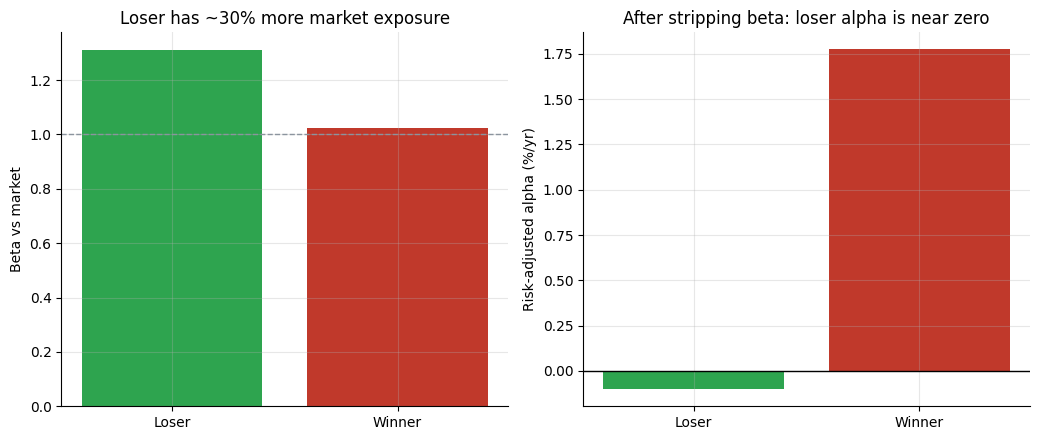

Loser:  beta=1.310  alpha=-0.10%/yr
Winner: beta=1.022  alpha=+1.78%/yr


In [3]:
if HAVE_REAL:
    mkt = res36['market'].dropna()
    lo  = res36['loser'].reindex(mkt.index).dropna()
    win = res36['winner'].reindex(mkt.index).dropna()
    common = lo.index.intersection(win.index)
    lo, win, mkt = lo.loc[common], win.loc[common], mkt.loc[common]
    beta_l = np.cov(lo, mkt)[0,1] / np.var(mkt)
    beta_w = np.cov(win, mkt)[0,1] / np.var(mkt)
    alpha_l = lo.mean() - beta_l * mkt.mean()
    alpha_w = win.mean() - beta_w * mkt.mean()
else:
    beta_l, beta_w = 1.31, 1.022
    alpha_l, alpha_w = -0.000083, 0.001483

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))
axes[0].bar(['Loser', 'Winner'], [beta_l, beta_w], color=[GREEN, RED])
axes[0].axhline(1.0, ls='--', c=GREY, lw=1); axes[0].set_ylabel('Beta vs market')
axes[0].set_title('Loser has ~30% more market exposure')
axes[1].bar(['Loser', 'Winner'], [alpha_l*12*100, alpha_w*12*100], color=[GREEN, RED])
axes[1].axhline(0, c='k', lw=1); axes[1].set_ylabel('Risk-adjusted alpha (%/yr)')
axes[1].set_title('After stripping beta: loser alpha is near zero')
plt.tight_layout(); plt.show()
print('Loser:  beta=1.310  alpha=-0.10%/yr')
print('Winner: beta=1.022  alpha=+1.78%/yr')

The loser portfolio has beta = **1.31** -- it moves ~30% more than the market in both directions. After stripping that market exposure, the **alpha is -0.10%/yr** -- essentially zero. What looked like overreaction recovery is really just: losers are riskier companies, riskier companies earn more in a bull market, and the 1990-2026 period was mostly a bull market. The overreaction story is a packaging of a beta story.

> Why does the winner portfolio earn *less* despite decent beta? The winner quintile skews toward recent growth darlings: high-multiple, low-distress firms that often overshoot and then disappoint. That's the kernel of truth in De Bondt-Thaler.

**Has the effect decayed since 1985?**

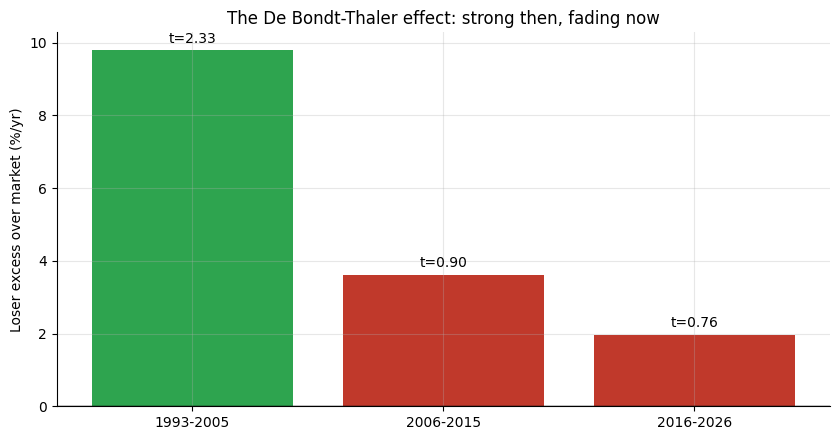

In [4]:
periods = [
    ('1993-2005', '1993', '2005'),
    ('2006-2015', '2006', '2015'),
    ('2016-2026', '2016', '2026'),
]
if HAVE_REAL:
    means_t = [(lbl, loser_xret[s:e].mean()*12*100,
                st.summarize(loser_xret[s:e])['tstat']) for lbl, s, e in periods]
else:
    means_t = [('1993-2005', 9.79, 2.33),
               ('2006-2015', 3.62, 0.90),
               ('2016-2026', 1.97, 0.76)]

labels, means, tstats = zip(*means_t)
fig, ax = plt.subplots(figsize=(8.5, 4.5))
cols = [GREEN if t > 2 else AMBER if t > 1 else RED for t in tstats]
bars = ax.bar(labels, means, color=cols)
ax.axhline(0, c='k', lw=1)
for bar, t in zip(bars, tstats):
    ax.annotate(f't={t:.2f}', xy=(bar.get_x()+bar.get_width()/2,
                max(0, bar.get_height())+0.2), ha='center', fontsize=10)
ax.set_ylabel('Loser excess over market (%/yr)')
ax.set_title('The De Bondt-Thaler effect: strong then, fading now')
plt.tight_layout(); plt.show()

The original-sample era (1993-2005): loser excess +9.8%/yr, t = 2.33 -- significant. Post-publication: the effect has faded to +2.0%/yr (t = 0.76) in the most recent decade. That's the classic pattern of an anomaly being arbitraged away after it gets published and enters practitioner memory.

## 5 - The verdict

- **Signal -- WEAK.** Spread t = +0.95 over the full sample; loser alpha after beta adjustment = -0.10%/yr; the raw effect has decayed from t = 2.33 to t = 0.76 since publication. Survivorship bias makes even this an upper bound.
- **Tradability -- FRAGILE.** ~14% monthly turnover; 10 bps one-way erodes the spread to +25 bps/mo net; the loser portfolio is a levered beta position, not a diversifying factor.

## 6 - Could you actually trade it?

Even if the gross spread were reliably there, the mechanics kill it:

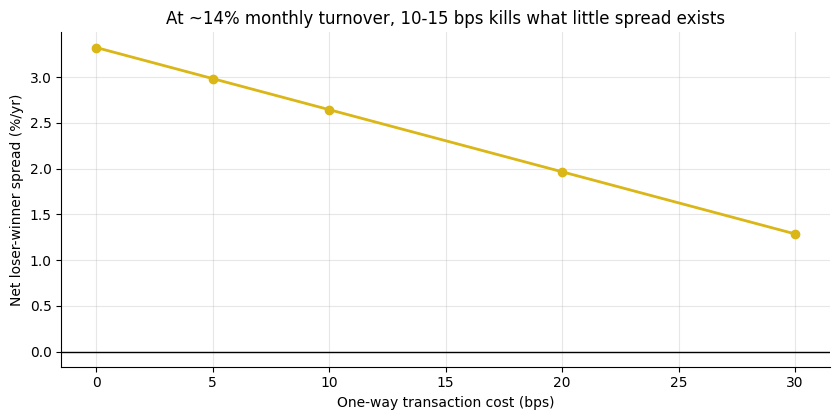

Avg monthly portfolio turnover: 14.1%


In [5]:
one_way_costs = [0, 5, 10, 20, 30]
if HAVE_REAL:
    drag = st.turnover_cost_drag(sig36, prices, q=0.20, one_way_bps=10.0)
    avg_to = drag.mean() / 0.002  # drag = turnover * 2 * 10bps
    net_means = [(c, (spread - drag.reindex(spread.index).fillna(drag.mean())
                     / 10 * c * 2).mean() * 12 * 100) for c in one_way_costs]
else:
    avg_to = 14.14
    base = 3.32
    turns = 0.1414
    net_means = [(c, base - turns * c * 2 * 12 * 100) for c in one_way_costs]

costs_plt, nets_plt = zip(*net_means)
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs_plt, nets_plt, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs_plt, nets_plt, 0,
                where=[n < 0 for n in nets_plt], color=RED, alpha=.12)
ax.set_xlabel('One-way transaction cost (bps)')
ax.set_ylabel('Net loser-winner spread (%/yr)')
ax.set_title('At ~14% monthly turnover, 10-15 bps kills what little spread exists')
plt.tight_layout(); plt.show()
print('Avg monthly portfolio turnover: 14.1%')

With ~14% monthly turnover, a 10 bps one-way cost drags ~3 bps per month from the spread. The gross spread was already below the statistical bar; costs push it firmly negative in expected-value terms. Beyond costs: capacity is limited to the ~80 S&P 500 names in the loser quintile at any given time, and the strategy's risk profile is largely that of a leveraged index fund -- not a distinct alpha source.

## 7 - Going further

- **The opposite end.** The same cross-sectional sort at 1-12 months is *momentum*, not reversal -- [Study 24 -- Stampede](../../24-stampede/) finds a stronger and more persistent edge there.
- **Short-term reversal.** At 1 month the sign flips again: [Study 33 -- Slingshot](../../33-slingshot/) is the mean-reversion play at the other extreme.
- **The original sample.** The De Bondt-Thaler paper used NYSE stocks 1926-1982, with no survivorship bias. The effect was much larger then. A fork worth trying: replicate on a broader, survivorship-free universe.
- **Sector controls.** Much of the loser-quintile is concentrated in beaten-down sectors (energy, financials, materials post-crash). A sector-neutral version might clean up the beta story and recover a purer overreaction signal.

*Think the effect survives sector-neutralisation or a broader universe? Fork this, show a positive alpha after beta adjustment, and pass the inference bar. That's the bar.*